Before you submit this assignment, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE".

# ES98E Assignment 2 - Sensitivity Analysis

## Workshop Aims

By the end of the workshop you should be able to:

- Calculate and plot first and second order sensitivities of a computational code with respect to its input parameters
- Understand the strengths and limitations of numerical and automatic approaches to differentiation of a code
- Optionally, explore how a low-dimensional subspace can be identified and exploited

**Note**: *The maximum available points for this assignment is 120: 100 points for the core material that everyone is expected to attempt, and 20 points for extension material which is optional, but assessed. The highest percentage you could get on this assignment without attempting the extension material is 100/120 = 83.3%*

In [53]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

from sensitivity import (count_calls, plot_sensitivities,
                         first_order_sensitivities, first_order_variance,
                         second_order_sensitivities)

from fluidsolvers import (poiseuille_solver_1,
                          poiseuille_solver_2,
                          poiseuille_solver_3, 
                          u_analytic,
                          Q_analytic)

# Customize default plotting style
%matplotlib inline
import seaborn as sns
sns.set_context('talk')

In [54]:
plt.rc('figure', figsize=(10, 8))

## Setup: Poiseuille Channel Flow

<center><img src="poiseuille.png" width="40%"></center>

In the Poiseuille channel flow problem illustrated above, the fluid velocity profile $u(y)$ is given by the solution of the ODE

$$
-G = \nu \, \frac{\partial^2 u}{\partial y^2}
$$

where $-W \le y \le W$ is the vertical position and $G$ and $\nu$ are constants, and the system is subject to no-slip boundary conditions $u(-W) = u(W) = 0$.

The analytic solution can be obtained by direct integration:

$$
u_\mathrm{analytic} = \frac{G}{2\nu}(W^2 - y^2)
$$

For our quantity of interest (QoI), we will use the volume flux $Q$, defined by

$$
Q = \int_{-W}^{W} u(y)\, \mathrm{d}y
$$

We can show by integrating $u_\mathrm{analytic}$ that the exact analytic solution for $Q$ is

$$
Q_\mathrm{analytic} =  \frac{2W^3G}{3\nu}
$$

Here we will simplify by combining the $G$ and $\nu$ parameters into a single driving force $F$ (which we will later allow to vary spatially to represent a random microstructure), giving

$$
-F = \frac{\partial^2 u}{\partial y^2} \\
u_\mathrm{analytic} = \frac{F}{2}(W^2 - y^2) \\
Q_\mathrm{analytic} =  \frac{2W^3F}{3}
$$

We'll consider three versions of the problem, all solved using a simple finite difference setup:

1. **Simple solver** `poiseuille_solver_1()`  where the input $\mathbf{x} = (F, W)$ is two-dimensional with $F \sim \mathcal{N}(1.0, 0.1^2)$ and $W \sim \mathcal{N}(2.0, 0.2^2)$.
2. **Spatially varying solver** `poiseuille_solver_2()` where the input $\mathbf{x} = (F_l, F_h, W)$ is three-dimensional with the imposed pressure gradient $F$ varying spatially with a lower pressure gradient $F_l$ slightly offset from the middle of the channel and a higher pressure gradient $F_h$ elsewhere:
$$
F(y) = \begin{cases}
F_l & 0 \le y \le W/2 \\
F_h & \text{otherwise}
\end{cases}
$$
The mean values of $F_l$ and $F_h$ to be 0.1 and 1.0 respectively, and their standard deviations to be 0.1 in both cases, giving three random parameters
$$
F_l \sim \mathcal{N}(0.1, 0.1^2) \\
F_h \sim \mathcal{N}(1.0, 0.1^2) \\
W \sim \mathcal{N}(2.0, 0.2^2) \\
$$
3. **High-dimensional solver** `poiseuille_solver_3()` where the input $\mathbf{x}$ is a random field giving the values of the pressure gradient at each of the $N$ grid points (with $N=1000$ by default). This variant is described in more detail in Part 2 below.

Python implementations of these solvers are provided in the [fluidsolvers](fluidsolvers.py) module. You are encouraged to inspect the code for the solvers to see how they work.

## Part 1: Sensitivity Analysis for Poiseuille solver

For the first version of the solver, `poiseuille_solver_1`, we'll treat $F$ and $W$ as the two random parameters of the model, independently distributed as follows:

$$
F \sim \mathcal{N}(1.0, 0.1^2) \\
W \sim \mathcal{N}(2.0, 0.2^2) \\
$$

### Question 1 

**(a) Tabulate the first-order sensitivities of $Q$ as returned by `poiseuille_solver_1` to the parameters $F$ and $W$ and plot a graph to illustrate these results. You should use the `plot_sensitivities()` function from the lecture notebook, which has already been imported from the [sensitivity](sensitivity.py) module provided** 

<div align="right">[10 points]</div>

First-order Sensitivities Table:


,parameter,mean,sigma,sensitivity,scaled_sensitivity,sensitivity_index
0,F,1.0,0.1,5.333371,5.333371,0.533337
1,W,2.0,0.2,7.999969,15.999939,1.599994


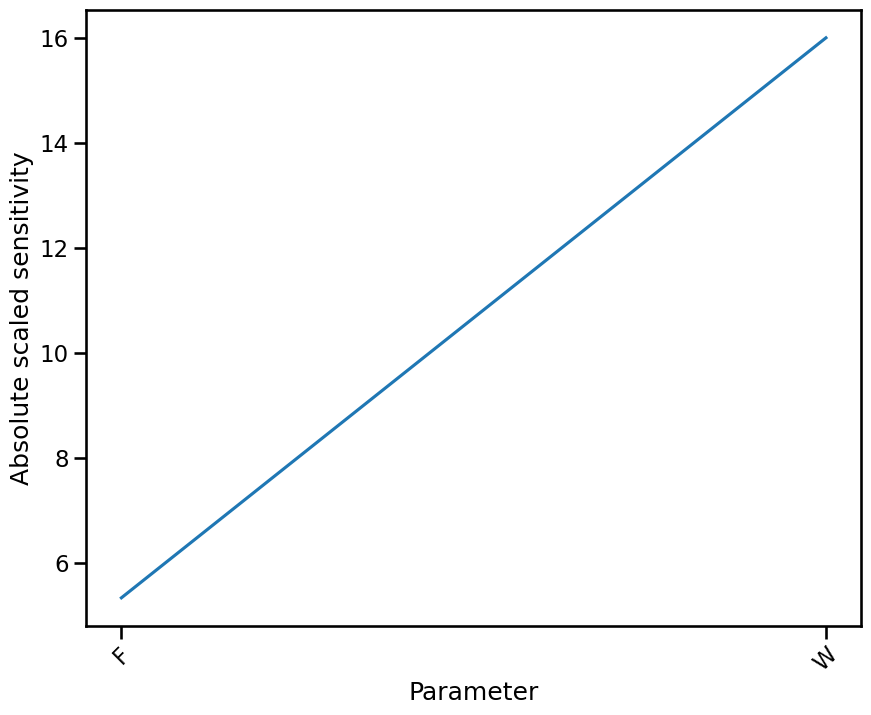

In [55]:
F = st.norm(1.0, 0.1)
W = st.norm(2.0, 0.2)
variables = [F, W]
variable_names = ['F', 'W']

df_sensitivities, ax = plot_sensitivities(poiseuille_solver_1, variables, variable_names)

print("First-order Sensitivities Table:")
display(df_sensitivities)

**(b) Confirm the values from your finite difference calculations agree with what you would expect from taking derivatives of the analytic solution for $Q$. Comment on the sensitivities of the model to each of the two parameters** 

<div align="right">[5 points derivation + 5 points numerical comparison]</div>

The analytical solution for Q is given by the equation $$Q_{\text{analytic}} = \frac{2W^3F}{3}.$$
The partial derivatives with respect to F and W are as follows:
$$\frac{\partial Q}{\partial F} = \frac{2W^3}{3},$$
$$\frac{\partial Q}{\partial W} = 2W^2F$$

We then compute the partial derivatives at their mean values $$\frac{\partial Q}{\partial F} \biggr |_{\mu=1.0} = \frac{2(2.0)^3}{3} \approx 5.333$$

$$ \frac{\partial Q}{\partial W} \biggr |_{\mu=2.0} = 2(2.0)^2(1.0)=8.0$$

In [56]:
analytical_sens = [16/3, 8.0]
numerical_sens = df_sensitivities['sensitivity'].values

for name, num, ana in zip(variable_names, numerical_sens, analytical_sens):
    error = abs(num - ana)
    print(f"Parameter {name}:")
    print(f"  Analytic Expectation: {ana:.4f}")
    print(f"  Numerical Result:     {num:.4f}")
    print(f"  Difference:           {error:.2e}")

Parameter F:
  Analytic Expectation: 5.3333
  Numerical Result:     5.3334
  Difference:           3.78e-05
Parameter W:
  Analytic Expectation: 8.0000
  Numerical Result:     8.0000
  Difference:           3.07e-05


The difference between the analytical and numerical computations is significantly small, showing that the finite difference calculations agree with the analytical solution for Q.

### Question 2

**Repeat the sensitivity analysis using version 2 of the solver, i.e. `poiseuille_solver_2()`, where we no longer have analytical results to compare with. Which of the the two parameters $F_l, F_h$ would you expect $Q$ to be more sensitive to? Do your results match your hypothesis? Store the returned DataFrame in a variable called `df` for use in Question 3.** 

- Recall that this version of the solver has low and high force regions with driving forces $F_l$ and $F_h$, respectively. 
- The lower pressure gradient $F_l$ region is slightly offset from the middle of the channel and a higher pressure gradient $F_h$ elsewhere:

$$
F(y) = \begin{cases}
F_l & 0 \le y \le W/2 \\
F_h & \text{otherwise}
\end{cases}
$$
- Assume $F_l \sim \mathcal{N}(0.1, 0.1^2)$ and $F_h \sim \mathcal{N}(1.0, 0.1^2)$. 
- The cell immediately below can be used to visualise the behaviour of this solver; there's nothing you need to change in that cell.

<div align="right">[5 points code + 5 points comments]</div>

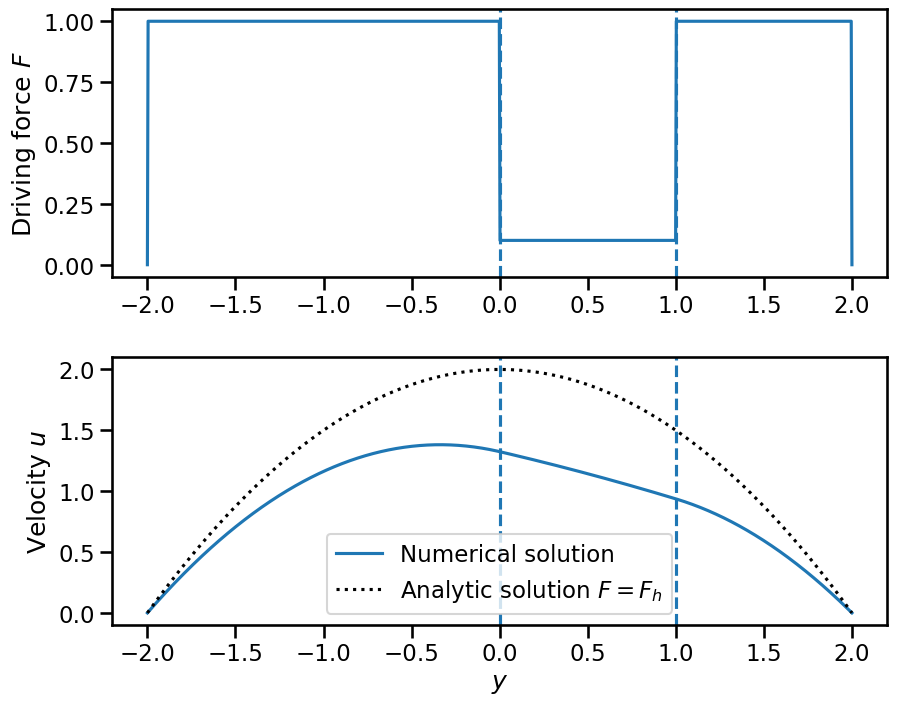

In [57]:
# use this cell to visualise the behaviour of poiseuille_solver_2()

F_l = 0.1
F_h = 1.0
W = 2.0
N = 1000

u, F, Q = poiseuille_solver_2([F_l, F_h, W], N=N, return_all=True)
y = np.linspace(-W, W, N)

fig, (ax1, ax2) = plt.subplots(2, 1)

ax1.plot(y, F)
ax2.plot(y, u, label='Numerical solution')

ax2.plot(y, u_analytic(y, F_h, W), 'k:', 
         label=f'Analytic solution $F=F_h$')
ax2.legend()

ax1.set_ylabel('Driving force $F$')
ax2.set_ylabel('Velocity $u$')
ax2.set_xlabel('$y$')

for ax in (ax1, ax2):
    ax.axvline(0, ls='dashed')
    ax.axvline(W/2, ls='dashed')

plt.subplots_adjust(hspace=0.3)

,parameter,mean,sigma,sensitivity,scaled_sensitivity,sensitivity_index
0,F_l,0.1,0.1,1.834813,0.183481,0.183481
1,F_h,1.0,0.1,3.498500,3.498500,0.349850
2,W,2.0,0.2,5.522950,11.045901,1.104590



Sensitivity to F_l: 1.8348
Sensitivity to F_h: 3.4985
Conclusion: The results MATCH the hypothesis (Sensitivity to F_h > Sensitivity to F_l).


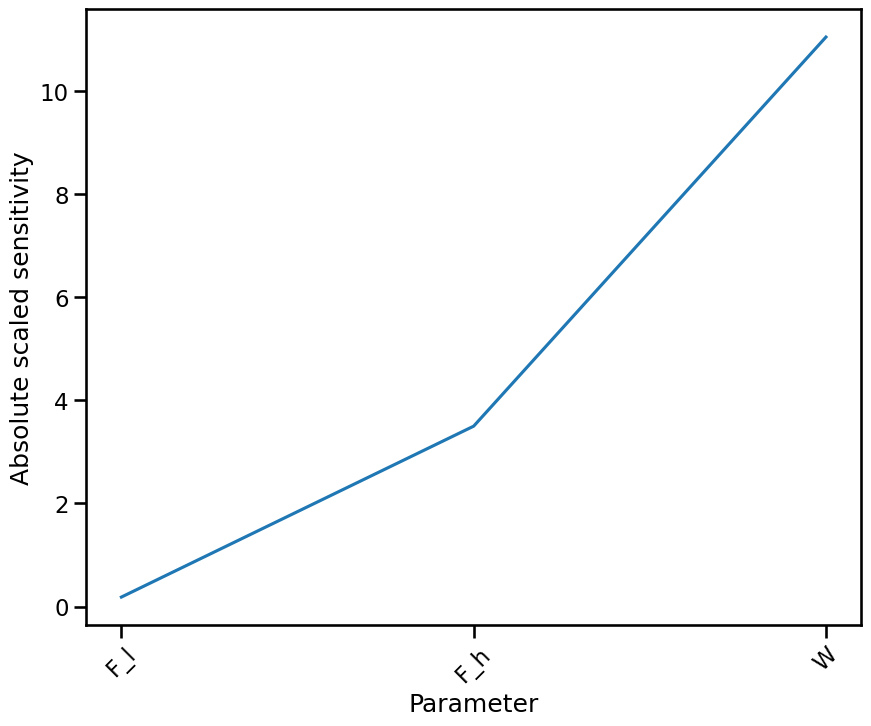

In [58]:
F_l = st.norm(0.1, 0.1)
F_h = st.norm(1.0, 0.1)
W = st.norm(2.0, 0.2)
variables = [F_l, F_h, W]
variable_names = ['F_l', 'F_h', 'W']

df, ax = plot_sensitivities(poiseuille_solver_2, variables, variable_names)
display(df)

# get sensitivities for different Fs
sens_Fl = df.loc[df['parameter'] == 'F_l', 'sensitivity'].values[0]
sens_Fh = df.loc[df['parameter'] == 'F_h', 'sensitivity'].values[0]

print(f"\nSensitivity to F_l: {sens_Fl:.4f}")
print(f"Sensitivity to F_h: {sens_Fh:.4f}")

if sens_Fh > sens_Fl:
    print("Conclusion: The results MATCH the hypothesis (Sensitivity to F_h > Sensitivity to F_l).")
else:
    print("Conclusion: The results DO NOT match the hypothesis.")

The volume flux $Q$ was expected to be more sensitive to $F_h$ than $F_l$, $F_h$ drives 75% of the channel as opposed to $F_l$, which drives 25%. 

### Question 3

**Use the first order variance method to estimate the overall variance in $Q$ for `poiseuille_solver_2()` resulting from the assumed variability in the input parameters and the sensitivities calculated in Question 2.**

You should use the `first_order_variance()` function from the sensitivity module, and store your result for the mean in the variable `Q_mean` and your result for the standard deviation in the variable `Q_std`. Treat the parameters as independent so that the covariance matrix is diagonal.

*Note:* This question uses the DataFrame `df` returned by your code in Question 2 - make sure you stored it in a variable called `df`.

<div align="right">[5 points]</div>

In [59]:
x0 = np.array([v.mean() for v in variables])
sigma0 = np.array([v.std() for v in variables])

covar_sigma = np.diag(sigma0**2)
dQdx = df['sensitivity'].values
var, Q_std = first_order_variance(dQdx, covar_sigma)
Q_mean = poiseuille_solver_2(x0)

print(f'Q = {Q_mean:.3f} +/- {Q_std:.3f}')

Q = 3.682 +/- 1.173


In [60]:
assert abs(Q_mean - 3.69) < 1e-2
assert abs(Q_std - 1.177) < 1e-2

### Question 4

**Write code to compute the mean and standard deviation of $Q$ using simple random sampling. Also write a short descriptive comparison between these results and the mean and variance obtained in Question 3 above. Comment on the accuracy vs. cost of the first order variance method and simple random sampling for this problem.** 

*Hint:* You need to propagate the uncertainties in $F_l$, $F_h$ and $W$ through the solver, assuming the parameters are independent and distributed with the given normal distributions. Store the resulting array of $Q$ in an array `Q` and use sufficient samples to converge the mean and standard deviation in $Q$ within 5% of their nominal values (which you can verify using the automatic test provided).

You can use [scipy.stats.norm](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html)`(mu, sigma)` to represent a normal distribution with mean `mu` and standard deviation `sigma`. Once you have a variable representing a distribution, you can use the [rvs()](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_continuous.rvs.html) method to generate a specified number of samples, e.g. for a single random variable $F$:

```python
F = st.norm(1.0, 0.1)  # define a normally distributed random variable with mean 1.0 and stddev 0.1
Fs = F.rvs(1000)       # return 1000 samples from the random variable F
```

<div align="right">[5 points code + 5 points comments]</div>

In [61]:
F_l = st.norm(0.1, 0.1)
F_h = st.norm(1.0, 0.1)
W = st.norm(2.0, 0.2)
variables = [F_l, F_h, W]

N = 2000
F_l_samples = F_l.rvs(N)
F_h_samples = F_h.rvs(N)
W_samples = W.rvs(N)

Q_values = []

for i in range(N):
    x_i = [F_l_samples[i], F_h_samples[i], W_samples[i]]

    q = poiseuille_solver_2(x_i)
    Q_values.append(q)
    
Q = np.array(Q_values)
Q_mean_mc = Q.mean()
Q_std_mc = Q.std()

print(f"Monte Carlo Mean: {Q_mean_mc:.4f}")
print(f"Monte Carlo Std:  {Q_std_mc:.4f}")

Monte Carlo Mean: 3.7917
Monte Carlo Std:  1.1564


In [62]:
assert abs(Q.mean() - 3.80)/3.80 < 0.05
assert abs(Q.std() - 1.20)/1.20 < 0.05

ANSWER
The Monte Carlo simulation yields a mean flux that is higher than the first order variance method used in Question 3 (3.82 vs 3.68 to 2 decimal places). This discrepancy in mean values is a result of how the different methods evaluate the values.

The first order method relies on a Taylor expansion truncation whereby the approximation takes the form $$\mathbb{E}[Q(W)] \approx Q(\mathbb{E}[W]).$$ The second order method include the second-order term in the Taylor expansion, $$\mathbb{E}[Q(W)] \approx Q(\mu) + \frac{1}{2}Q''(\mu)\sigma^2.$$ This shows the true mean is proportional to the variance; the linear first-order approach does not account for this, whereas the second order approach does, and thus the MC approximation is closer to the true value. The MC approximation has a higher computational cost, calling the solver function 2000 times to yield the mean value, as opposed to the single function in Question 3.

## Part 2: High-dimensional Poiseuille flow problem

We will take one further step in complexity, by considering a case where the driving force $F(y)$, and hence also the sensitivity varies spatially. We'll do this by modelling the *mean value* of the driving force $F$ by the expression used in v2 of the solver, namely
$$
F(y) = \begin{cases}
F_l & 0 \le y \le W/2 \\
F_h & \text{otherwise}
\end{cases}
$$
with additional noise on top of this mean. The parameters are the $N$ values of $F$ at each node on the grid, which we can denote by a vector $\mathbf{F}$ (in this case, we will fix the values of the channel width $W$). We could think of $\mathbf{F}$ as representing a random porous media where either the pressure gradient or the viscosity changes with position.

A stochastic process like this which depends on a spatial coordinate is often called a *random field*. Let's modify our solver according to these definitions.  We'll stick with $N=1000$ nodes; note that our new solver has this many parameters, i.e. $p=N=1000$. The solver has already been imported from the `fluidsolvers` module, but here is the code for completeness:

```python
def poiseuille_solver_3(F, W=2, return_all=False):
    N = len(F)
    F = F.copy()  # avoid modifying input
    F[0] = F[-1] = 0  # enforce boundary conditions on RHS
    h = 2*W/(N-1)
    A = sparse.dia_matrix((N, N)) # assemble matrix A

    # Build diagonals with boundary condition modifications
    main_dia = np.ones(N) * 2/h**2
    main_dia[0] = main_dia[-1] = 1  # enforce u[0] = u[-1] = 0
    upper_dia = np.ones(N-1) * -1/h**2
    upper_dia[0] = 0  # no coupling at left boundary
    lower_dia = np.ones(N-1) * -1/h**2
    lower_dia[-1] = 0  # no coupling at right boundary

    A.setdiag(main_dia)
    A.setdiag(upper_dia,  1)
    A.setdiag(lower_dia, -1)
    A = A.tocsc() # convert to CSC storage for efficient solve
    u = linalg.spsolve(A, F) # parameter vector specifies RHS
    Q = np.sum(u)*h
    if return_all:
        return u, F, Q
    else:
        return Q
```

### Question 5

**Test v3 of the solver by passing in the vector of driving forces $\mathbf{F}$ returned by v2 of the solver using $F_l = 0.1$, $F_h=1.0$, $W=2.0$, storing the results for $u$, $F$ and $Q$ with each solver in variables named `u2, u3, F2, F3, Q2, Q3`. You should get the same results for the velocity profile $\mathbf{u}$ and flow rate $Q$ in both cases**

<div align="right">[5 points]</div>

In [63]:
F_l = 0.1
F_h = 1.0
W = 2.0

u2, F2, Q2 = poiseuille_solver_2([F_l, F_h, W], return_all=True)
u3, F3, Q3 = poiseuille_solver_3(force_2, W=W, return_all=True)

if np.allclose(u2, u3) and np.isclose(Q2, Q3):
    print("Solvers yielded similar results.")

else:
    print("Results do not match.")

Solvers yielded similar results.


In [64]:
assert abs(Q2 - Q3) < 1e-6
assert np.abs(u2 - u3).max() < 1e-8


### Question 6

**Repeat the sensitivity analysis for v3 of the solver with respect to the $N$ input values comprising the vector $\mathbf{F}$, plotting a graph of the scaled sensitivities as a function of position $y$ (with $-W \le y \le W$).**

<div align="right">[15 points]</div>

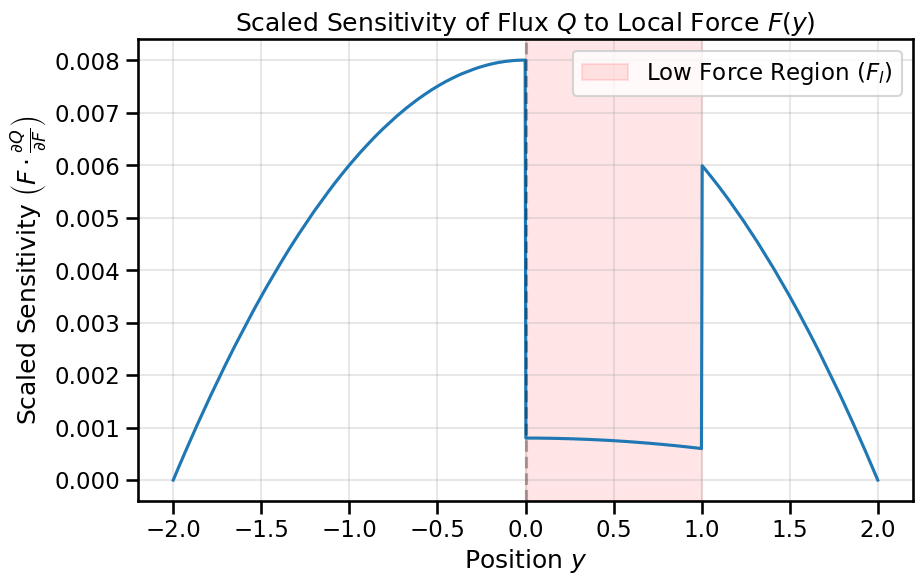

In [65]:
# YOUR CODE HERE
N = 1000
W = 2.0
y = np.linspace(-W, W, N)

mean = np.ones(N) * 1.0
mean[(y >= 0) & (y <= W/2)] = 0.1

solve = lambda F: poiseuille_solver_3(F, W=W)
Q_0 = solve(mean)
sensitivities = first_order_sensitivities(solve, mean, Q_0)

scaled_sens = mean * sensitivities

plt.figure(figsize=(10, 6))
plt.plot(y, scaled_sens)
plt.axvspan(0, W/2, color='red', alpha=0.1, label='Low Force Region ($F_l$)')
plt.axvline(0, color='k', linestyle='--', alpha=0.3)
plt.xlabel('Position $y$')
plt.ylabel(r'Scaled Sensitivity $\left( F \cdot \frac{\partial Q}{\partial F} \right)$')
plt.title('Scaled Sensitivity of Flux $Q$ to Local Force $F(y)$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Part 3: Automatic differentiation with JAX

The [jax](https://jax.readthedocs.io/) package implements [automatic differentiation](https://en.wikipedia.org/wiki/Automatic_differentiation) of Python and numpy code, which can be extremely handy for sensitivity analysis and other UQ tasks. 
However, it mainly wraps `numpy`, and doesn't have support for the direct sparse linear algebra we used in the solver. (There is [an iterative sparse solver](https://jax.readthedocs.io/en/latest/jax.scipy.html#module-jax.scipy.sparse.linalg) in JAX, if you need it for a research project, and there are also differentiable linear solvers in the [lineax](https://docs.kidger.site/lineax/) package). JAX also supports just-in-time compilation of Python code for CPU or GPU which can speed up code massively. We won't use these features here but will return to them in later lectures.

Let's rewrite our solver with dense linear algebra and try out `jax.grad`. We'll write a single function that works for both the original 2-dimensional `2d` and high-dimensional `hd` cases (not the 3d case with $F_l$ and $F_h$; that's left as an extension exercise).

In [66]:
from jax import config
config.update("jax_enable_x64", True)     # use double rather than single precision floats
config.update('jax_platform_name', 'cpu') # use CPU rather than GPU

import jax.numpy as jnp
from jax import grad

def poiseuille_solver_jax(x, N=1000, return_all=False, mode='2d', W=2.0, nu=0.5):
    if mode == '2d':
        F, W = x # unpack parameters, overwritting defaults
        y = jnp.linspace(-W, W, N)
        F = F * jnp.ones(N)
    elif mode == 'hd':
        F = x # parameters give us a vector for F(y)
        N = len(x) # override N with length of input vector
    else:
        raise ValueError(f'unknown mode: {mode}')

    # Enforce boundary conditions on RHS
    F = F.at[0].set(0)
    F = F.at[-1].set(0)

    h = 2 * W / (N-1)
    A = 2 * jnp.eye(N) - jnp.eye(N, k=-1) - jnp.eye(N, k=+1)
    A *= 1. / h**2

    # Enforce boundary conditions on matrix (u[0] = u[-1] = 0)
    A = A.at[0, :].set(0)
    A = A.at[0, 0].set(1)
    A = A.at[-1, :].set(0)
    A = A.at[-1, -1].set(1)

    u = jnp.linalg.solve(A, F)
    Q = jnp.sum(u) * h
    if return_all:
        return u, F, Q
    else:
        return Q

### Question 7

**Write a test to verify numerically that you get the same answers with the JAX solver and the original `poiseuille_solver_1()`**

*Hint:* you should check for agreement within some precision, since there will be small numerical differences between the two solvers. Agreement within $10^{-6}$ would be sufficient.

<div align="right">[5 points]</div>

In [67]:
F, W = 1.0, 2.0
x = np.array([F, W])

Q_po1 = poiseuille_solver_1(x)
Q_jax = poiseuille_solver_jax(x, mode='2d')

difference = abs(Q_po1 - float(Q_jax))
assert difference < 1e-6, f"Solvers have significant difference: {difference}"

Now we use the `jax.grad()` function, which returns a new function that computes the derivative of its input with respect to the first argument. We try out our new function on the input vector `x`, and compare with the reference results from finite differences:

In [68]:
grad_poiseuille_solver_jax = grad(poiseuille_solver_jax)
grad_poiseuille_solver_jax(x, mode='2d')

Array([5.33332799, 7.99999198], dtype=float64)

In [69]:
Q0 = poiseuille_solver_1(x)
first_order_sensitivities(poiseuille_solver_1, x, Q0)

array([5.33337112, 7.99996928])

In [70]:
grad_poiseuille_solver_jax(x) - first_order_sensitivities(poiseuille_solver_1, x, Q0)

Array([-4.31305053e-05,  2.27001330e-05], dtype=float64)

Pretty good agreement - recall that the default step-size `eps` used in `first_order_sensitivities` is $10^{-6}$, so an error of this order is to be expected. Next, we compare the time taken for the automatic derivation and finite differences:

In [71]:
%timeit first_order_sensitivities(poiseuille_solver_1, x, Q0)

1.93 ms ± 113 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [72]:
%timeit grad_poiseuille_solver_jax(x)

198 ms ± 29.8 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


The automatic differentiation is actually slower than finite differences here! This is because our solver is very simple and the number of parameters is low! 

Let's try with the high-dimensional version, as before first to check the answers match the finite-difference ones reasonably well. Here `Fbar` is the vector of driving-forces values used in questions 5 and 6.

In [73]:
Q3 = poiseuille_solver_3(F2)
np.abs(grad_poiseuille_solver_jax(F2, mode='hd') - 
       first_order_sensitivities(poiseuille_solver_3, F2, Q3)).max()

1.4384360194429069e-05

### Question 8

**Explore how the time for finite difference and autograd change as you increase the number of nodes $N$, and estimate the crossover where it becomes more efficient to use autograd. Illustrate your results with a suitable graph.** 

*Hint:* the `%timeit` macro takes a `-o` argument which you can use to return the time taken. Run `? %timeit` in an empty cell for details.

<div align="right">[10 points code + 10 points plot + 10 points explanation]</div>

Use this cell for your benchmark code

In [74]:
from jax import grad

Ns = [10, 100, 200, 500, 1000, 2000]
finite_differences = []
jaxs = []

for N in Ns:
    F = np.ones(N)

    def finite_diff_wrapper(vec):
        return poiseuille_solver_3(vec, W=2.0)

    Q_0 = finite_diff_wrapper(F)

    # %timeit flags documentation: https://ipython.readthedocs.io/en/stable/interactive/magics.html#magic-timeit
    # -o: returns a TimeitResult object
    # -q: quiet mode, prevents stdout
    # -n 1: executes only once
    # -r 1: repeats the run 1 time for stability
    fd_time = %timeit -o -q -n 1 -r 1 first_order_sensitivities(finite_diff_wrapper, F, Q_0)
    # .average yields a value rather than appending the timeit obj.
    finite_differences.append(fd_time.average)

    grad_solve = grad(poiseuille_solver_jax)
    grad_solve(F, mode='hd')
    jax_time = %timeit -o -q -n 10 -r 3 grad_solve(F, mode='hd')
    jaxs.append(jax_time.average)

Use the cell below for your plotting code

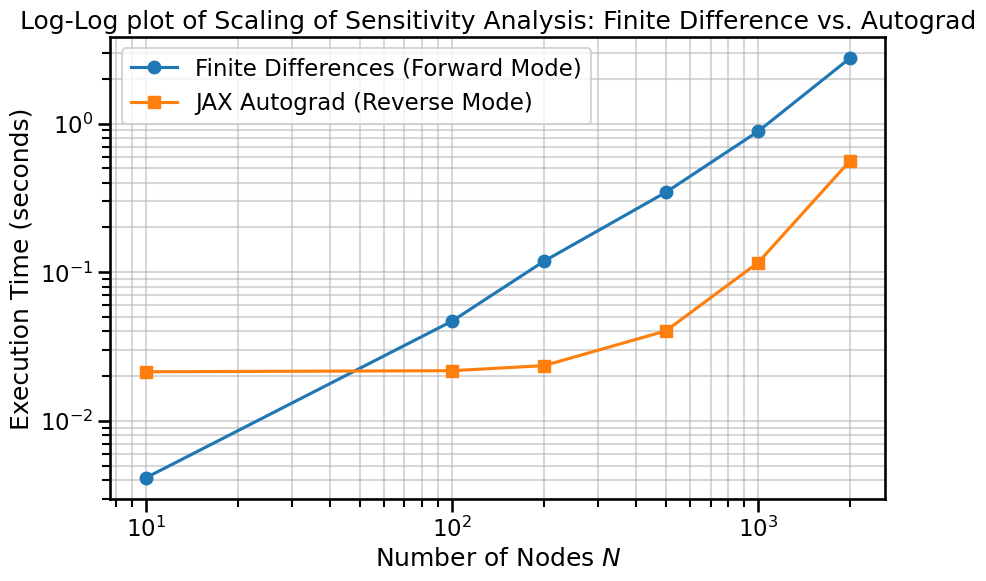

In [77]:
plt.figure(figsize=(10, 6))

plt.loglog(Ns, finite_differences, 'o-', label='Finite Differences (Forward Mode)')
plt.loglog(Ns, jaxs, 's-', label='JAX Autograd (Reverse Mode)')

plt.xlabel('Number of Nodes $N$')
plt.ylabel('Execution Time (seconds)')
plt.title('Log-Log plot of Scaling of Sensitivity Analysis: Finite Difference vs. Autograd')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()

plt.show()

The graph shows the finite differences method scales linearly as the number of inputs increases, whereas the JAX implementation goes from flat to a slow increase as N grows. The crossover line is around $N \approx 50$. Finite differences is significantly more performant before the crossover point, primarily because of JAX's JIT compilation, but for large N the autodifferentiation framework is more performant.

## Extension Section - checking for low-dimensional active sub-spaces

As well as reducing the number of evaluations needed to perform sensitivity analysis as seen in the lecture, another application of regression methods is to identify low-dimensional active subspaces.

Constantine proposes a ["quick-and-dirty"](https://arxiv.org/abs/1402.3838) visual check for a low-dimensional active subspace based on computing a linear approximation of the function that is often very useful as a first thing to try when investigating a new problem.

The essence of the approach as applied to an $m$-dimensional function $f(\mathbf{x})$ where $\mathbf{x} = (x_1, \ldots x_m)$ is as follows:

1. Draw $N$ samples $\hat{\mathbf{x}}_j$ uniformly from $[-1, 1]^m$
2. Let $\mathbf{x}_j = \frac 12 \left[ (\mathbf{x}^u - \mathbf{x}^l) \cdot \hat{\mathbf{x}}_j + (\mathbf{x}^u + \mathbf{x}^l) \right]$, where $\mathbf{x}^l$ and $\mathbf{x}^u$ are vectors of the lower- and upper-bounds for each variable, respectively. **NB: the $\cdot$ represents element-wise multiplication of matrices, not matrix multiplication**
3. Evaluate the model at the sample points and store in a vector $\mathbf{f} = (f(\mathbf{x}_1), \ldots, f(\mathbf{x}_N) )$
4. Compute the coefficients of the linear regression model
$$
f(\mathbf{x}) = \hat{a}_0 + \hat{a}_1 \hat{x}_1 + \ldots \hat{a}_m\hat{x}_m
$$
using least squares
$$
\hat{\mathbf{a}} = \text{argmin}_\mathbf{u} \| \hat{\mathbf{X}} \mathbf{u} - \mathbf{f} \|^2
$$
where
$$
\hat{\mathbf{X}} = \begin{bmatrix}
1 & \hat{\mathbf{x}}_1 \\
\vdots & \vdots \\
1 & \hat{\mathbf{x}}_N
\end{bmatrix}, \; \;
\hat{\mathbf{a}} = \begin{bmatrix}
\hat{a}_0 \\
\vdots \\
\hat{a}_m
\end{bmatrix}
$$
5. Let $\mathbf{w} = \mathbf{a}' / \| \mathbf{a}' \|$, where $\mathbf{a}'$ are the last $m$ coefficients (i.e. the gradient) of the linear regression approximation.
6. Produce a scatter plot of $\mathbf{w}^T \hat{\mathbf{x}}_j$ versus $f_j$ and visually inspect for a one-dimensional subspace

### Extension Question 1

**Apply Constantine's "quick-and-dirty" method to the two-dimensional Poiseuille flow problem**

Starting from the template provided below, apply steps 1-5 of the method described above to `poiseuille_solver_1()`, which is a two-dimensional problem (i.e. $m=2$) with random variables

$$
F \sim \mathcal{N}(1.0, 0.1^2) \\
W \sim \mathcal{N}(2.0, 0.2^2) \\
$$

Use $N=100$ samples and set $\mathbf{x}^l$ and $\mathbf{x}^u$ to the mean plus/minus 2 standard deviations for each dimension. Use variable names `xl`, `xu`, `X`, `Xhat` and `f` for $\mathbf{x}^l$, $\mathbf{x}^u$, $\mathbf{X}$,  $\hat{\mathbf{X}}$ and $\mathbf{f}$, respectively. Some of the code is provided for you, but you will need to fill in  expressions for `xl`, `xu` `Xhat`, `X` and `f`.

<div align="right">[10 points]</div>

In [80]:
m = 2    # number of dimensions
N = 100  # number of samples

mu = np.array([1.0, 2.0])
sigma = np.array([0.1, 0.2])

xl = mu - 2 * sigma
xu = mu + 2 * sigma
samples = np.random.uniform(-1,1,size=(N,m))

X = 0.5 * ((xu - xl) * Xhat + (xu+xl))
f = np.array([poiseuille_solver_1(row) for row in X])

Xhat = np.hstack([np.ones((N,1)), samples])

# fit linear regression model, and compute its gradient
ahat = np.linalg.lstsq(Xhat, f, rcond=None)[0]
w = ahat[1:] / np.linalg.norm(ahat[1:])
print(w)

[0.90040597 0.43505067]


In [81]:
assert Xhat.shape == (N, m+1)
assert Xhat.min() >= -1 and Xhat.max() <= +1

assert X.shape == (N, m)
assert np.all(X[:, 0].min() >= xl[0])
assert np.all(X[:, 1].min() >= xl[1])
assert np.all(X[:, 0].max() <= xu[0])
assert np.all(X[:, 1].max() <= xu[1])


### Extension Question 2

**Produce a scatter plot as described in step 6 of the "quick-and-dirty" method above. Add a suitable line/curve of best fit (e.g. using [numpy.polyfit()](https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html)) to your plot, and comment on your results.**

**Hint:** Is there any connection between the vector $\mathbf{w}$ and the quantities $\partial Q/\partial F$ and $\partial Q/\partial W$ evaluated in Question 1(b)?

<div align="right">[5 points code/plot + 5 points discussion]</div>

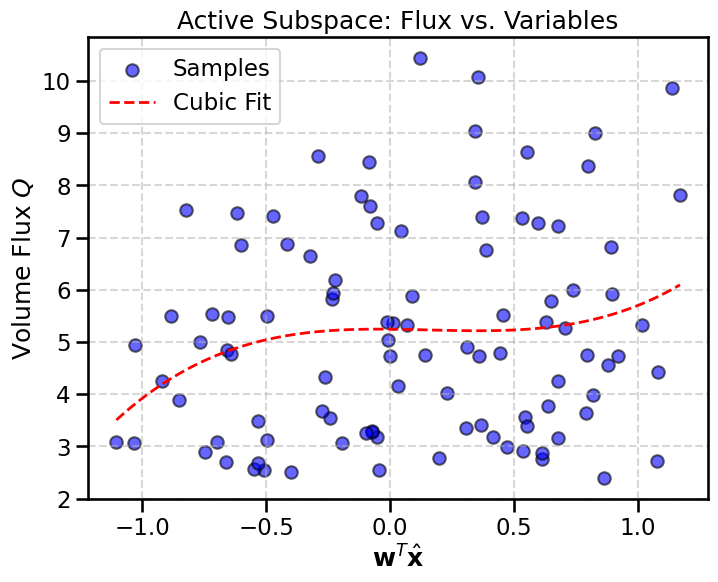

In [89]:
var = samples @ w

coeffs = np.polyfit(var, f, 3)
polynomial = np.poly1d(coeffs)

x_smooth = np.linspace(var.min(), var.max(), 100)
y_smooth = polynomial(x_smooth)

plt.figure(figsize=(8, 6))
plt.scatter(var, f, alpha=0.6, label='Samples', color='blue', edgecolors='k')
plt.plot(x_smooth, y_smooth, 'r--', linewidth=2, label=f'Cubic Fit')

plt.xlabel(r'$\mathbf{w}^T \hat{\mathbf{x}}$')
plt.ylabel(r'Volume Flux $Q$')
plt.title("Active Subspace: Flux vs. Variables")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

The plot shows the data samples are scattered and do not conform to a cubic line of best fit.

### Extension Question 3

**Compare the quick-and-dirty method with finding the rotation of a 3D surface plot which collapses the data onto a line**

Recall that the analytic solution for this problem is

$$
Q_\mathrm{analytic} =  \frac{2W^3F}{3}
$$

Use the `Q_analytic` Python function provided in the `fluidsolvers` module that implements $Q_\mathrm{analytic}(F, W)$ together with the visualisation code provided below to overlay a surface plot of $Q_\mathrm{analytic}(F, W)$ on a 3D scatter plot of the data sampled above. By rotating this plot interactively, confirm for yourself that there is a one-dimensional active subspace in a direction that is consistent with the vector $\mathbf{w}$ you obtained above.

<div align="right">[Not for credit]</div>

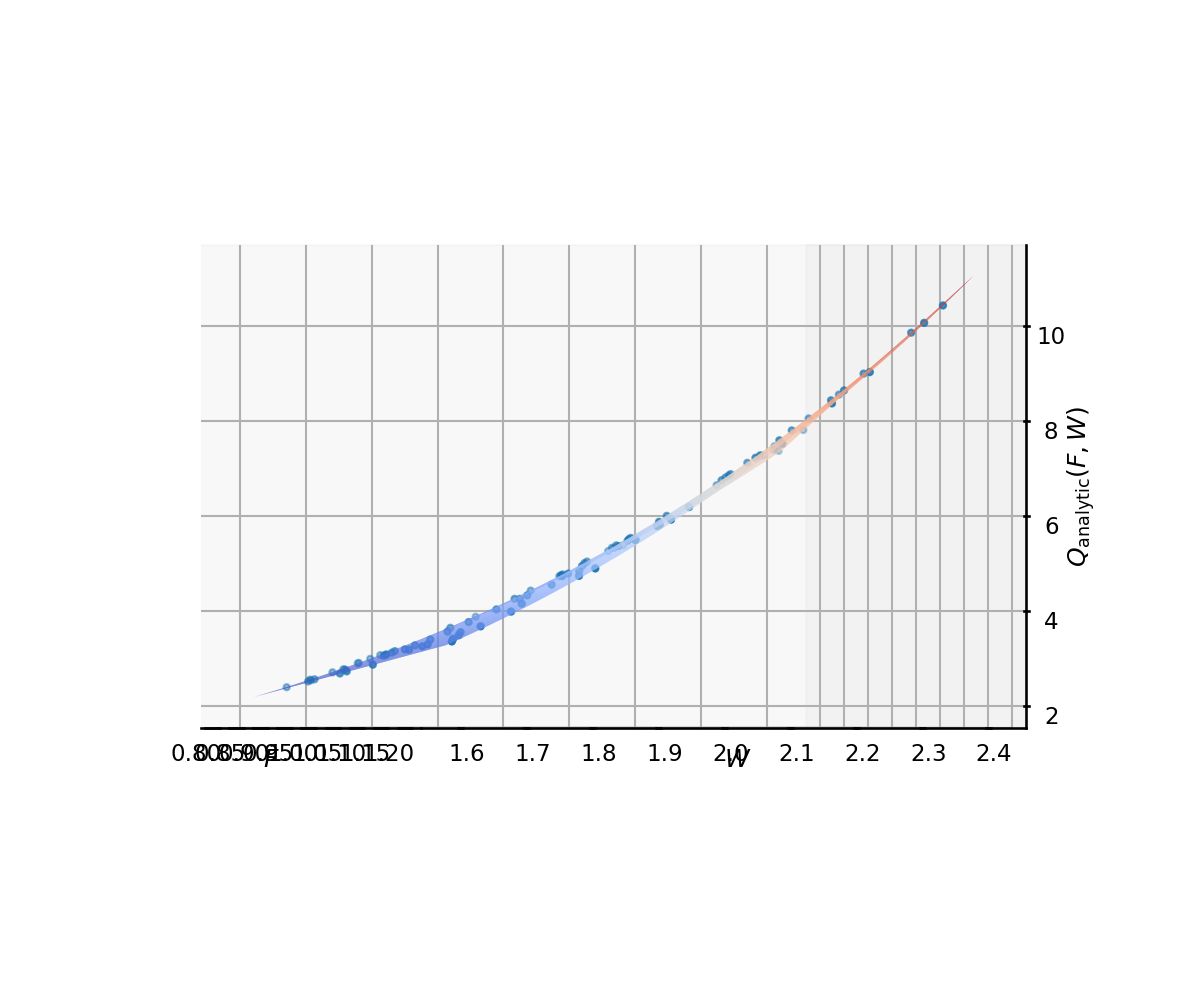

In [90]:
# different backend needed for interactive rotation of 3D plots
%matplotlib widget
plt.rc('figure', figsize=(12, 10))

# 3D plot of model for comparison, rotated by hand to collapse into 2 dimensions - grab and rotate to see!
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d', proj_type='ortho')

F = np.linspace(xl[0], xu[0], 100)
W = np.linspace(xl[1], xu[1], 100)

FF, WW = np.meshgrid(F, W)
QQ = Q_analytic(FF, WW)
surf = ax.plot_surface(FF, WW, QQ, cmap=plt.cm.coolwarm)

ax.scatter(xs=X[:, 0], ys=X[:, 1], zs=f)
ax.view_init(0, -20)

ax.set_xlabel('$F$')
ax.set_ylabel('$W$')
ax.set_zlabel(r'$Q_\mathrm{analytic}(F, W)$')

fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

In [91]:
# back to standard backend to avoid messing up other cells
%matplotlib inline